# NIFTY direction v2 — open-to-close, overnight cues and institutional flows

### 1. A better-posed target
Predicts **open-to-close**: `y = 1 if Close(d) > Open(d)`. You buy at the open and
sell at the close. Crucially this also *unlocks* the gap as a feature — at the moment
you act, the open is known.

### 2. Information that isn't already in the close

v1's 17 features were all summaries of one price series. v2 adds two blocks:

| Block | Features | Known by |
|---|---|---|
| **Global** | overnight S&P 500 and Nasdaq, India VIX level and change, USDINR, Brent, and the gap itself | US session ends before NSE opens |
| **Flows** | FII / DII / retail positioning in index futures and options, and the day-on-day *change* in it | published after close on d-1 |

Everything is lagged so that it is knowable before the trade. The notebook builds the
feature blocks **cumulatively** so you can see which block, if any, actually adds signal.

### 3. Two model families, not one

Every block is fitted with **logistic regression** (linear, interpretable) and with
**k-nearest neighbours** (non-parametric, able to pick up non-linear structure a line
cannot). Both sit behind the same scaler and the same chronological CV, so the comparison
is like for like — §7 races them.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
SEED = 42
START = "2017-01-01"   # FII/DII participant archive begins here

In [2]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, RED, ORANGE, AQUA, VIOLET = "#2a78d6", "#e34948", "#eb6834", "#1baf7a", "#4a3aa7"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "font.family": ["DejaVu Sans"], "font.size": 9,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.dpi": 110,
})

def style(ax, title=None, sub=None):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, pad=16 if sub else 8)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=8.5,
                color=MUTED, ha="left", va="bottom")
    return ax

SEQ = mpl.colors.LinearSegmentedColormap.from_list(
    "seq", ["#cde2fb", "#86b6ef", "#3987e5", "#2a78d6", "#1c5cab", "#0d366b"])

## 2. Data

In [3]:
def yf_close(ticker, field="Close"):
    d = yf.download(ticker, start=START, auto_adjust=False, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.droplevel(1)
    return d

px = yf_close("^NSEI")[["Open", "High", "Low", "Close", "Volume"]].copy()
px["Volume"] = px["Volume"].replace(0, np.nan).ffill()
px = px.dropna()

spx   = yf_close("^GSPC")["Close"].pct_change()      # US session ends after NSE close
ndx   = yf_close("^IXIC")["Close"].pct_change()
vix   = yf_close("^INDIAVIX")["Close"]
inr   = yf_close("INR=X")["Close"].pct_change()
brent = yf_close("BZ=F")["Close"].pct_change()

print(f"NIFTY {len(px):,} days  {px.index.min().date()} -> {px.index.max().date()}")
for n, s in [("S&P 500", spx), ("Nasdaq", ndx), ("India VIX", vix),
             ("USDINR", inr), ("Brent", brent)]:
    print(f"  {n:11s} {len(s.dropna()):>5,} rows")

NIFTY 2,396 days  2017-01-02 -> 2026-09-18
  S&P 500     2,439 rows
  Nasdaq      2,439 rows
  India VIX   2,381 rows
  USDINR      2,526 rows
  Brent       2,443 rows


### FII / DII flows

This one is not on Yahoo, and it is worth being precise about what is and isn't
obtainable, because the obvious source doesn't have history:

| Source | What it gives | Usable for a backtest? |
|---|---|---|
| NSE `api/fiidiiTradeReact` | headline **cash-market** FII/DII, current day only | No — no history |
| StockEdge `FIIDashboardApi` | cash + derivatives, FII and DII | No — hard-capped at the last **10** sessions |
| **NSE participant-wise archive** | **daily FII / DII / retail / proprietary positioning in equity derivatives, 2017 → today** | **Yes** |

So the flow block is built on institutional **derivatives positioning**, not the headline
cash figure. That is a real and widely-watched flow signal — and unlike the FII-only
derivatives file, it includes DII and retail too, which lets us use retail as a
contrarian indicator.

`fetch_flows.py` caches it. NSE throttles sustained parallel requests, so it paces itself
and resumes from cache — the first run takes a few minutes.

In [4]:
CACHE = Path("data/participant_oi.csv")
if not CACHE.exists():
    import fetch_flows
    fetch_flows.main()

flows = pd.read_csv(CACHE, index_col=0, parse_dates=True).sort_index()
# some NSE daily files print numbers Indian-style ("80,776.00") - one such row turns a
# whole column into strings, so coerce defensively rather than trusting the cache
flows = flows.apply(lambda c: pd.to_numeric(
    c.astype(str).str.replace(",", "", regex=False), errors="coerce"))
flows = flows.ffill()
print(f"{len(flows):,} days  {flows.index.min().date()} -> {flows.index.max().date()}")
print(f"{flows.shape[1]} raw columns, e.g. {list(flows.columns[:3])}")
flows.filter(like="FII|").head(3)

2,393 days  2017-01-02 -> 2026-09-17
24 raw columns, e.g. ['Client|Future Index Long', 'Client|Future Index Short', 'Client|Option Index Call Long']


,FII|Future Index Long,FII|Future Index Short,FII|Option Index Call Long,FII|Option Index Put Long,FII|Option Index Call Short,FII|Option Index Put Short
2017-01-02,109357.0,53167.0,189164.0,329766.0,191780.0,73753.0
2017-01-03,108661.0,52823.0,202192.0,348384.0,196566.0,77809.0
2017-01-04,112627.0,53995.0,215079.0,360075.0,200434.0,85796.0


## 3. Target: open-to-close

In [5]:
oc = (px["Close"] - px["Open"]) / px["Open"]          # what we can actually trade
cc = px["Close"].pct_change()                          # v1's target
gap = (px["Open"] - px["Close"].shift(1)) / px["Close"].shift(1)

y = (oc > 0).astype(int)

print(f"open-to-close  up rate {(oc > 0).mean():.2%}   mean |move| {oc.abs().mean():.3%}")
print(f"close-to-close up rate {(cc > 0).mean():.2%}   mean |move| {cc.abs().mean():.3%}")
print(f"overnight gap  up rate {(gap > 0).mean():.2%}   mean |move| {gap.abs().mean():.3%}")

open-to-close  up rate 47.37%   mean |move| 0.561%
close-to-close up rate 54.01%   mean |move| 0.687%
overnight gap  up rate 66.74%   mean |move| 0.404%


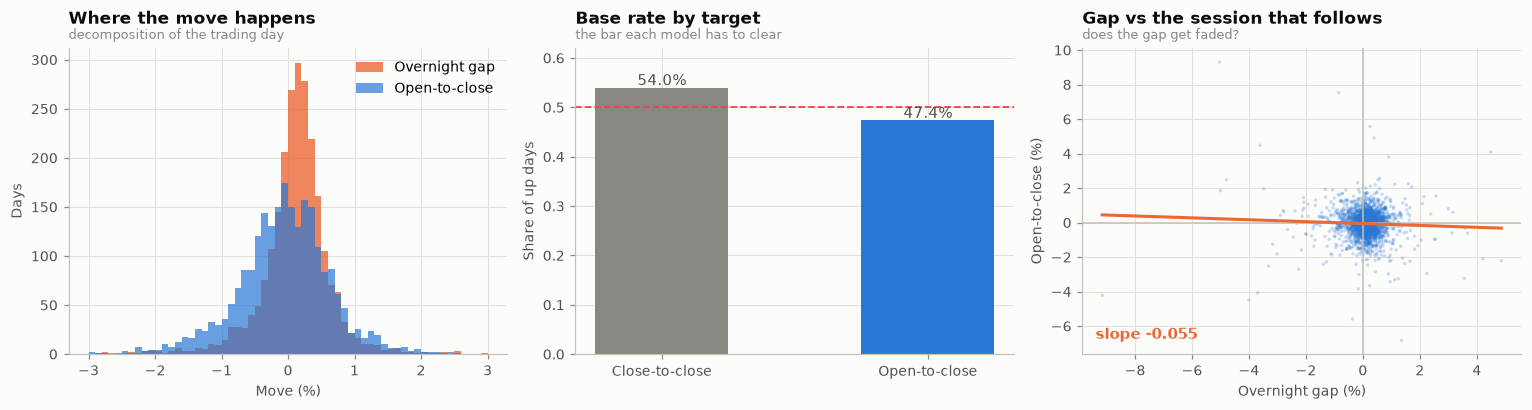

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = style(axes[0], "Where the move happens", "decomposition of the trading day")
parts = pd.DataFrame({"Overnight gap": gap, "Open-to-close": oc}).dropna()
ax.hist(parts["Overnight gap"] * 100, bins=np.linspace(-3, 3, 61), color=ORANGE,
        alpha=0.8, label="Overnight gap")
ax.hist(parts["Open-to-close"] * 100, bins=np.linspace(-3, 3, 61), color=BLUE,
        alpha=0.7, label="Open-to-close")
ax.set_xlabel("Move (%)"); ax.set_ylabel("Days"); ax.legend()

ax = style(axes[1], "Base rate by target", "the bar each model has to clear")
rates = {"Close-to-close": (cc > 0).mean(), "Open-to-close": (oc > 0).mean()}
bars = ax.bar(list(rates), list(rates.values()), color=[MUTED, BLUE], width=0.5)
for b, v in zip(bars, rates.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.1%}", ha="center",
            fontsize=10, color=INK2)
ax.axhline(0.5, color=RED, ls="--", lw=1.2)
ax.set_ylim(0, 0.62); ax.set_ylabel("Share of up days")

ax = style(axes[2], "Gap vs the session that follows", "does the gap get faded?")
d = pd.DataFrame({"gap": gap, "oc": oc}).dropna()
ax.scatter(d["gap"] * 100, d["oc"] * 100, s=5, color=BLUE, alpha=0.25, edgecolors="none")
ax.axhline(0, color=AXIS, lw=1); ax.axvline(0, color=AXIS, lw=1)
b, a = np.polyfit(d["gap"], d["oc"], 1)
xs = np.linspace(d["gap"].min(), d["gap"].max(), 50)
ax.plot(xs * 100, (a + b * xs) * 100, color=ORANGE, lw=2)
ax.set_xlabel("Overnight gap (%)"); ax.set_ylabel("Open-to-close (%)")
ax.text(0.03, 0.05, f"slope {b:+.3f}", transform=ax.transAxes, color=ORANGE,
        fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

Note the middle panel: the open-to-close base rate is much closer to 50% than
close-to-close. Drift lives mostly in the overnight gap, not the session — so this target
is both more tradeable *and* harder to fake with a constant prediction.

The third panel is the effect v2 is betting on: a negative slope would mean gaps get
faded during the session.

## 4. Features — with the timing spelled out

The alignment rule, stated once and applied everywhere:

- a feature dated **d-1** is lagged one day, because the day-d session is what we predict;
- the **gap and the open** of day d are *not* lagged — they are known at the moment we act;
- foreign series are reindexed onto the NSE calendar **then** lagged, so a US or holiday
  calendar mismatch cannot pull tomorrow's value into today.

Getting that shift wrong by one day is the single easiest way to manufacture a fake result.

In [7]:
idx = px.index

def lag1(s):
    # onto the NSE calendar, then lagged: value known before the day-d open
    return s.reindex(idx).ffill().shift(1)

F = pd.DataFrame(index=idx)

# ---- Block A: price history (v1's family, trimmed of near-duplicates) -------
ret = cc
for w in (5, 10, 20):
    F[f"ma_{w}"] = lag1(ret.rolling(w).mean())
    F[f"sd_{w}"] = lag1(ret.rolling(w).std())
for w in (3, 6, 9):
    F[f"mom_{w}"] = lag1(ret.rolling(w).sum())
F["vol_3"] = lag1(px["Volume"].rolling(3).mean() / px["Volume"].rolling(30).mean() - 1)
F["oc_prev"] = lag1(oc)
PRICE = list(F.columns)

# ---- Block B: overnight / global ------------------------------------------
F["gap"] = gap                      # NOT lagged: known at the open we trade
F["spx"] = lag1(spx)
F["ndx"] = lag1(ndx)
F["vix"] = lag1(vix)
F["vix_chg"] = lag1(vix.pct_change())
F["inr"] = lag1(inr)
F["brent"] = lag1(brent)
GLOBAL = [c for c in F.columns if c not in PRICE]

# ---- Block C: FII / DII / retail positioning -------------------------------
def net_fut(who):
    return flows[f"{who}|Future Index Long"] - flows[f"{who}|Future Index Short"]

def net_opt(who):
    # directional index-option positioning: long calls + short puts = bullish
    return ((flows[f"{who}|Option Index Call Long"] + flows[f"{who}|Option Index Put Short"])
            - (flows[f"{who}|Option Index Put Long"] + flows[f"{who}|Option Index Call Short"]))

for who in ("FII", "DII", "Client"):
    tag = who.lower()
    nf, no = net_fut(who), net_opt(who)
    scale = (flows[f"{who}|Future Index Long"] + flows[f"{who}|Future Index Short"]).rolling(60).mean()
    F[f"{tag}_fut_net"] = lag1(nf / scale)                 # positioning level
    F[f"{tag}_fut_chg"] = lag1(nf.diff() / scale)          # the day's flow
    F[f"{tag}_opt_net"] = lag1(no / scale)
FLOW = [c for c in F.columns if c not in PRICE + GLOBAL]

F = F.replace([np.inf, -np.inf], np.nan)
data = F.join(y.rename("y")).dropna()
X, y_ = data[F.columns], data["y"]

print(f"{len(X):,} days x {X.shape[1]} features   {X.index.min().date()} -> {X.index.max().date()}")
print(f"  price  {len(PRICE):>2}: {PRICE}")
print(f"  global {len(GLOBAL):>2}: {GLOBAL}")
print(f"  flows  {len(FLOW):>2}: {FLOW}")

2,336 days x 27 features   2017-03-30 -> 2026-09-18
  price  11: ['ma_5', 'sd_5', 'ma_10', 'sd_10', 'ma_20', 'sd_20', 'mom_3', 'mom_6', 'mom_9', 'vol_3', 'oc_prev']
  global  7: ['gap', 'spx', 'ndx', 'vix', 'vix_chg', 'inr', 'brent']
  flows   9: ['fii_fut_net', 'fii_fut_chg', 'fii_opt_net', 'dii_fut_net', 'dii_fut_chg', 'dii_opt_net', 'client_fut_net', 'client_fut_chg', 'client_opt_net']


A leakage check worth doing explicitly rather than trusting: no feature column should be
*perfectly* correlated with the target, and the gap — the one unlagged feature — should
correlate with the target only weakly. A correlation near ±1 means something from day d's
close leaked in.

strongest single correlation with the target: 0.0507  (oc_prev)


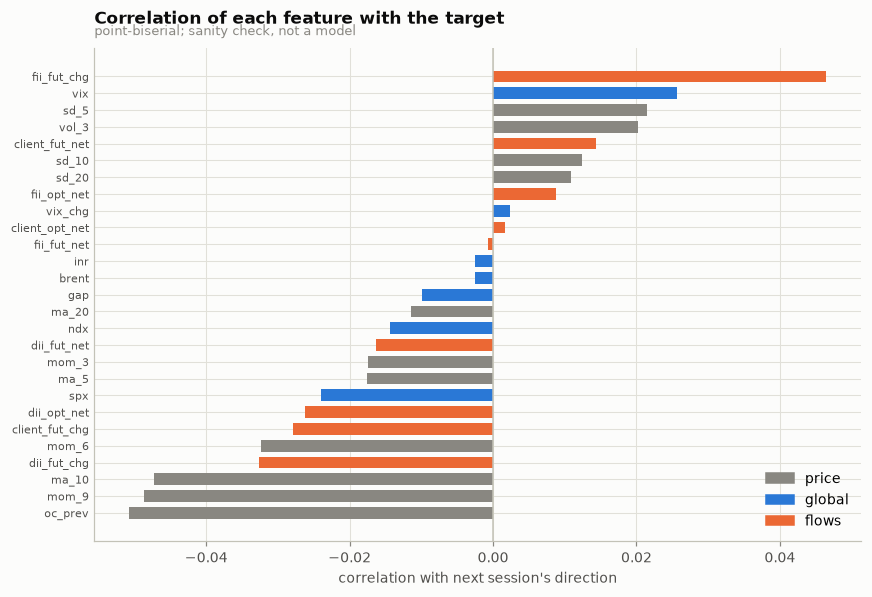

In [8]:
corr = X.apply(lambda c: np.corrcoef(c, y_)[0, 1]).sort_values()
print(f"strongest single correlation with the target: {corr.abs().max():.4f}"
      f"  ({corr.abs().idxmax()})")
assert corr.abs().max() < 0.5, "suspiciously high — check the lags"   # leakage shows up near 0.9

fig, ax = plt.subplots(figsize=(8, 5.5))
style(ax, "Correlation of each feature with the target",
      "point-biserial; sanity check, not a model")
block = {**{c: "price" for c in PRICE}, **{c: "global" for c in GLOBAL},
         **{c: "flows" for c in FLOW}}
cmap = {"price": MUTED, "global": BLUE, "flows": ORANGE}
ax.barh(corr.index, corr.values, color=[cmap[block[c]] for c in corr.index], height=0.7)
ax.axvline(0, color=AXIS, lw=1)
ax.tick_params(axis="y", labelsize=7.5, length=0)
ax.set_xlabel("correlation with next session's direction")
handles = [mpl.patches.Patch(color=v, label=k) for k, v in cmap.items()]
ax.legend(handles=handles, loc="lower right")
plt.tight_layout(); plt.show()

## 5. Ablation — does each block earn its place?

Rather than throwing everything in at once, fit the blocks cumulatively. If the global or
flow block carries real information, AUC should step up when it is added. If it doesn't,
we will see that just as clearly — and that is the result either way.

Same protocol as v1: chronological 80/20 split, scaler inside the pipeline, `C` chosen by
`TimeSeriesSplit` on the training portion only. `class_weight="balanced"` stops the model
collapsing onto the majority class the way v1 did.

In [9]:
split = len(X) - int(len(X) * 0.20)
X_tr_idx, X_te_idx = X.index[:split], X.index[split:]
y_tr, y_te = y_.iloc[:split], y_.iloc[split:]
print(f"train {X_tr_idx[0].date()} -> {X_tr_idx[-1].date()}  ({len(X_tr_idx):,} days)")
print(f"test  {X_te_idx[0].date()} -> {X_te_idx[-1].date()}  ({len(X_te_idx):,} days)")
print(f"test base rate (always-up): {max(y_te.mean(), 1 - y_te.mean()):.2%}")


KNN_GRID = {"clf__n_neighbors": [5, 15, 25, 50, 75, 100, 150, 200, 300],
            "clf__weights": ["uniform", "distance"]}


def build(kind):
    if kind == "lr":
        clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)
        return clf, {"clf__C": np.logspace(-4, 2, 13)}
    clf = KNeighborsClassifier()            # scaling matters far more here than for LR
    return clf, KNN_GRID


def run(cols, name, kind="lr"):
    Xs = X[cols]
    clf, param_grid = build(kind)
    pipe = Pipeline([("scale", StandardScaler()), ("clf", clf)])
    grid = GridSearchCV(pipe, param_grid, cv=TimeSeriesSplit(5),
                        scoring="roc_auc", n_jobs=-1)
    grid.fit(Xs.iloc[:split], y_tr)
    m = grid.best_estimator_
    p = m.predict_proba(Xs.iloc[split:])[:, 1]
    pred = (p > 0.5).astype(int)
    params = (f"C={grid.best_params_['clf__C']:.0e}" if kind == "lr" else
              f"k={grid.best_params_['clf__n_neighbors']}, "
              f"{grid.best_params_['clf__weights']}")
    return {
        "name": name, "kind": kind, "n_features": len(cols), "params": params,
        "cv_auc": grid.best_score_, "test_auc": roc_auc_score(y_te, p),
        "accuracy": accuracy_score(y_te, pred),
        "balanced_acc": balanced_accuracy_score(y_te, pred),
        "proba": p, "pred": pred, "model": m, "cols": cols, "grid": grid,
    }


COLS = ["name", "n_features", "params", "cv_auc", "test_auc", "accuracy", "balanced_acc"]

runs = [
    run(PRICE,                  "A. Price only"),
    run(PRICE + GLOBAL,         "B. + Global / overnight"),
    run(PRICE + GLOBAL + FLOW,  "C. + FII/DII flows"),
    run(["gap"],                "gap alone (1 feature)"),
    run(GLOBAL + FLOW,          "Global + flows, no price"),
]

table = pd.DataFrame([{k: r[k] for k in COLS} for r in runs]).set_index("name")
table.round(4)

train 2017-03-30 -> 2024-10-29  (1,869 days)
test  2024-10-30 -> 2026-09-18  (467 days)
test base rate (always-up): 53.32%


,n_features,params,cv_auc,test_auc,accuracy,balanced_acc
name,,,,,,
A. Price only,11,C=3e-02,0.5194,0.5502,0.5503,0.5472
B. + Global / overnight,18,C=1e-04,0.5090,0.5613,0.5503,0.5512
C. + FII/DII flows,27,C=1e+01,0.5262,0.4907,0.5246,0.5054
gap alone (1 feature),1,C=1e-04,0.4622,0.5029,0.5182,0.5105
"Global + flows, no price",16,C=1e+02,0.5117,0.4738,0.4904,0.4804


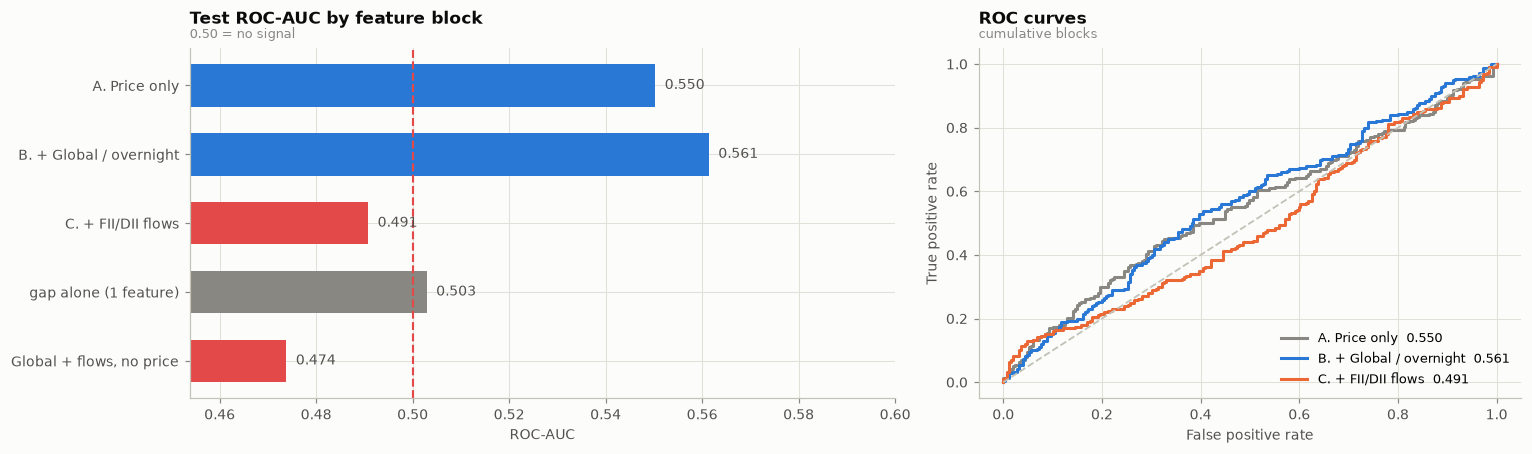

In [10]:
base = max(y_te.mean(), 1 - y_te.mean())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})

ax = style(axes[0], "Test ROC-AUC by feature block", "0.50 = no signal")
names = [r["name"] for r in runs]
aucs = [r["test_auc"] for r in runs]
cols = [BLUE if a >= 0.53 else (MUTED if a >= 0.50 else RED) for a in aucs]
bars = ax.barh(names, aucs, color=cols, height=0.62)
for b, a in zip(bars, aucs):
    ax.text(a + 0.002, b.get_y() + b.get_height() / 2, f"{a:.3f}",
            va="center", fontsize=9, color=INK2)
ax.axvline(0.5, color=RED, ls="--", lw=1.4)
ax.set_xlim(min(0.47, min(aucs) - 0.02), max(0.60, max(aucs) + 0.03))
ax.invert_yaxis(); ax.set_xlabel("ROC-AUC")

ax = style(axes[1], "ROC curves", "cumulative blocks")
for r, c in zip(runs[:3], [MUTED, BLUE, ORANGE]):
    fpr, tpr, _ = roc_curve(y_te, r["proba"])
    ax.plot(fpr, tpr, color=c, label=f"{r['name']}  {r['test_auc']:.3f}")
ax.plot([0, 1], [0, 1], color=AXIS, ls="--", lw=1.2)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout(); plt.show()

## 6. The best block, in detail

In [11]:
best = max(runs[:3], key=lambda r: r["test_auc"])
print(f"best cumulative block: {best['name']}  (AUC {best['test_auc']:.4f})\n")
print(classification_report(y_te, best["pred"], target_names=["Down", "Up"],
                            digits=3, zero_division=0))

best cumulative block: B. + Global / overnight  (AUC 0.5613)

              precision    recall  f1-score   support

        Down      0.585     0.538     0.561       249
          Up      0.517     0.564     0.539       218

    accuracy                          0.550       467
   macro avg      0.551     0.551     0.550       467
weighted avg      0.553     0.550     0.551       467



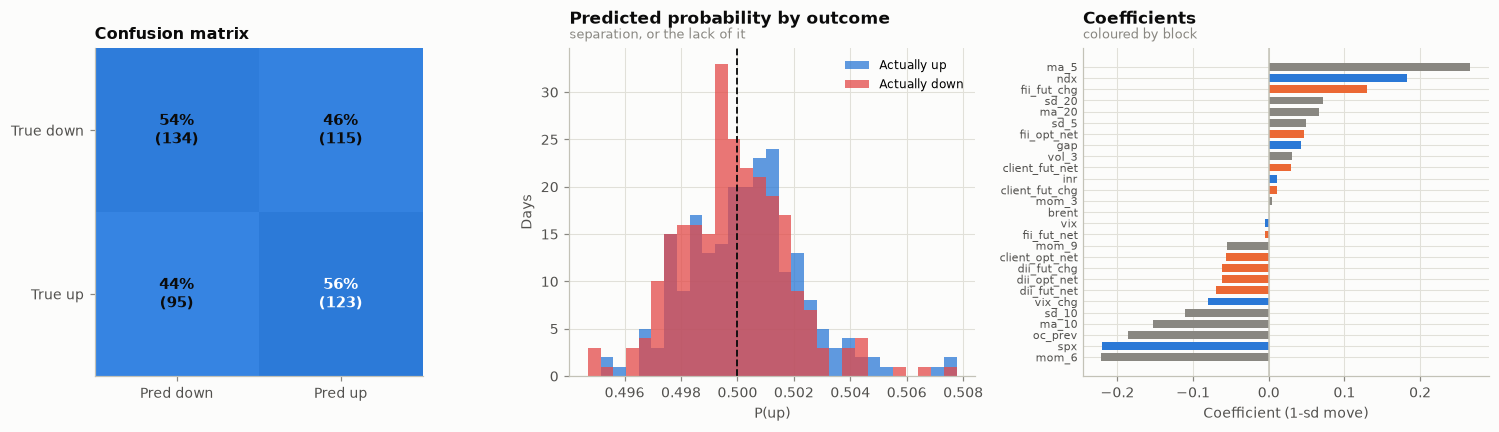

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
cm = confusion_matrix(y_te, best["pred"])
cmn = cm / cm.sum(axis=1, keepdims=True)
ax.imshow(cmn, cmap=SEQ, vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cmn[i, j]:.0%}\n({cm[i, j]})", ha="center", va="center",
                fontsize=10, fontweight="bold", color="white" if cmn[i, j] > 0.55 else INK)
ax.set_xticks([0, 1], ["Pred down", "Pred up"])
ax.set_yticks([0, 1], ["True down", "True up"])
ax.set_title("Confusion matrix", fontsize=10.5); ax.grid(False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax = style(axes[1], "Predicted probability by outcome", "separation, or the lack of it")
bins = np.linspace(best["proba"].min(), best["proba"].max(), 30)
ax.hist(best["proba"][y_te.values == 1], bins=bins, color=BLUE, alpha=0.75, label="Actually up")
ax.hist(best["proba"][y_te.values == 0], bins=bins, color=RED, alpha=0.75, label="Actually down")
ax.axvline(0.5, color=INK, ls="--", lw=1.2)
ax.set_xlabel("P(up)"); ax.set_ylabel("Days"); ax.legend(fontsize=8)

ax = style(axes[2], "Coefficients", "coloured by block")
full = runs[2]
coef = pd.Series(full["model"].named_steps["clf"].coef_[0], index=full["cols"]).sort_values()
ax.barh(coef.index, coef.values, color=[cmap[block[c]] for c in coef.index], height=0.7)
ax.axvline(0, color=AXIS, lw=1)
ax.tick_params(axis="y", labelsize=7, length=0)
ax.set_xlabel("Coefficient (1-sd move)")
plt.tight_layout(); plt.show()

## 7. A second model: k-nearest neighbours

Logistic regression can only draw a straight line through the feature space. If the
relationship is non-linear — "buy when the gap is small *and* volatility is low, but not
when momentum is extreme" — a linear model cannot express it and KNN can, because it
makes no functional assumption at all: it just asks what happened on the most similar
days in the past.

Two things to watch, and they pull in opposite directions:

- **Scaling is not optional.** KNN measures distance, so an unscaled feature with a big
  range would dominate every neighbour calculation. The `StandardScaler` already in the
  pipeline does this, fit on training folds only, exactly as before.
- **The curse of dimensionality.** With 27 features, "nearest" stops meaning much —
  in high dimensions every point is roughly equidistant from every other. Expect the
  smaller feature blocks to do relatively better here, which is the reverse of what
  usually happens with more features.

`k` is swept from 5 to 300. Small `k` fits noise; large `k` converges toward the base
rate. Financial data is noisy enough that the useful `k` is usually large.

In [13]:
knn_runs = [
    run(PRICE,                 "A. Price only",           kind="knn"),
    run(PRICE + GLOBAL,        "B. + Global / overnight", kind="knn"),
    run(PRICE + GLOBAL + FLOW, "C. + FII/DII flows",      kind="knn"),
]

knn_table = pd.DataFrame([{k: r[k] for k in COLS} for r in knn_runs]).set_index("name")
knn_table.round(4)

,n_features,params,cv_auc,test_auc,accuracy,balanced_acc
name,,,,,,
A. Price only,11,"k=300, uniform",0.5082,0.5674,0.5525,0.5238
B. + Global / overnight,18,"k=300, uniform",0.5135,0.4971,0.5310,0.5017
C. + FII/DII flows,27,"k=200, distance",0.5188,0.4938,0.5118,0.5016


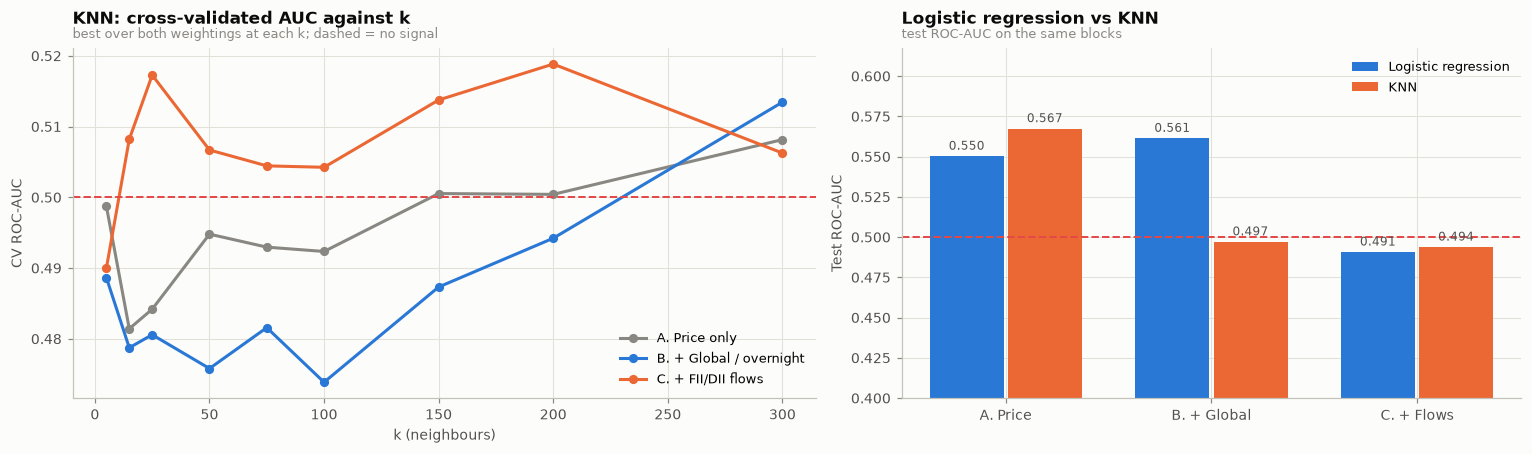

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})

ax = style(axes[0], "KNN: cross-validated AUC against k",
           "best over both weightings at each k; dashed = no signal")
for r, colr in zip(knn_runs, [MUTED, BLUE, ORANGE]):
    cv = pd.DataFrame(r["grid"].cv_results_)
    best_per_k = cv.groupby("param_clf__n_neighbors")["mean_test_score"].max()
    ax.plot(best_per_k.index.astype(int), best_per_k.values, color=colr,
            marker="o", ms=5, label=r["name"])
ax.axhline(0.5, color=RED, ls="--", lw=1.3)
ax.set_xlabel("k (neighbours)"); ax.set_ylabel("CV ROC-AUC")
ax.legend(loc="lower right", fontsize=8.5)

ax = style(axes[1], "Logistic regression vs KNN", "test ROC-AUC on the same blocks")
names = [r["name"] for r in knn_runs]
xs = np.arange(len(names))
lr_auc = [next(x["test_auc"] for x in runs if x["name"] == n) for n in names]
kn_auc = [r["test_auc"] for r in knn_runs]
ax.bar(xs - 0.19, lr_auc, width=0.36, color=BLUE, label="Logistic regression")
ax.bar(xs + 0.19, kn_auc, width=0.36, color=ORANGE, label="KNN")
for x, (a, b) in enumerate(zip(lr_auc, kn_auc)):
    ax.text(x - 0.19, a + 0.004, f"{a:.3f}", ha="center", fontsize=8, color=INK2)
    ax.text(x + 0.19, b + 0.004, f"{b:.3f}", ha="center", fontsize=8, color=INK2)
ax.axhline(0.5, color=RED, ls="--", lw=1.3)
ax.set_xticks(xs, ["A. Price", "B. + Global", "C. + Flows"])
ax.set_ylim(0.40, max(max(lr_auc), max(kn_auc)) + 0.05)
ax.set_ylabel("Test ROC-AUC"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

In [15]:
best_knn = max(knn_runs, key=lambda r: r["test_auc"])
print(f"best KNN: {best_knn['name']}  ({best_knn['params']})  "
      f"test AUC {best_knn['test_auc']:.4f}\n")
print(classification_report(y_te, best_knn["pred"], target_names=["Down", "Up"],
                            digits=3, zero_division=0))

combined = pd.concat([table.assign(model="logistic"),
                      knn_table.assign(model="knn")]).sort_values("test_auc",
                                                                 ascending=False)
combined[["model", "n_features", "params", "cv_auc", "test_auc",
          "accuracy", "balanced_acc"]].round(4)

best KNN: A. Price only  (k=300, uniform)  test AUC 0.5674

              precision    recall  f1-score   support

        Down      0.546     0.956     0.695       249
          Up      0.645     0.092     0.161       218

    accuracy                          0.552       467
   macro avg      0.596     0.524     0.428       467
weighted avg      0.592     0.552     0.445       467



,model,n_features,params,cv_auc,test_auc,accuracy,balanced_acc
name,,,,,,,
A. Price only,knn,11,"k=300, uniform",0.5082,0.5674,0.5525,0.5238
B. + Global / overnight,logistic,18,C=1e-04,0.5090,0.5613,0.5503,0.5512
A. Price only,logistic,11,C=3e-02,0.5194,0.5502,0.5503,0.5472
gap alone (1 feature),logistic,1,C=1e-04,0.4622,0.5029,0.5182,0.5105
B. + Global / overnight,knn,18,"k=300, uniform",0.5135,0.4971,0.5310,0.5017
C. + FII/DII flows,knn,27,"k=200, distance",0.5188,0.4938,0.5118,0.5016
C. + FII/DII flows,logistic,27,C=1e+01,0.5262,0.4907,0.5246,0.5054
"Global + flows, no price",logistic,16,C=1e+02,0.5117,0.4738,0.4904,0.4804


Two things to read carefully here.

**KNN gets worse as features are added** — 0.567 on price alone, then 0.497, then 0.494.
That is the curse of dimensionality arriving on schedule: at 27 features the "nearest"
300 days are barely more similar to today than any random 300 days. Logistic regression
did the opposite, improving from block A to B. This is the clearest practical argument
for keeping the feature set small when using a distance-based model.

**KNN's accuracy hides a lopsided classifier.** Look at its recall: 0.956 on Down and
0.092 on Up. Unlike the logistic model it has no `class_weight="balanced"` equivalent
here, so it simply votes with the local base rate — and since the open-to-close session
is down-biased, it says "down" almost every day. Its AUC is respectable because *ranking*
is still informative, but its 0.5 threshold is nearly useless. Balanced accuracy tells
the truer story: 0.524 for KNN against 0.551 for logistic regression.

## 8. Walk-forward and P&L

One split is one draw, so repeat the exercise honestly: expanding window, refit every 21
days, score only unseen days. Then convert the signal into a return stream — long at the
open and out at the close when the model says up, flat otherwise.

In [16]:
# block B won for both model families, so race them on it. Hyperparameters are the ones
# each family chose on the training split; re-tuning inside every refit would be honest
# too, just far slower, and the choice was made without touching the test period.
cols_wf = PRICE + GLOBAL
knn_b = next(r for r in knn_runs if r["name"].startswith("B."))
k_best = knn_b["grid"].best_params_["clf__n_neighbors"]
w_best = knn_b["grid"].best_params_["clf__weights"]


def walk_forward(make_clf, cols, step=21, min_train=500):
    rows = []
    for start in range(min_train, len(X), step):
        end = min(start + step, len(X))
        m = Pipeline([("scale", StandardScaler()), ("clf", make_clf())]
                     ).fit(X[cols].iloc[:start], y_.iloc[:start])
        p = m.predict_proba(X[cols].iloc[start:end])[:, 1]
        rows.append(pd.DataFrame({"proba": p, "pred": (p > 0.5).astype(int),
                                  "y": y_.iloc[start:end].values,
                                  "oc": oc.reindex(X.index).iloc[start:end].values},
                                 index=X.index[start:end]))
    out = pd.concat(rows)
    out["hit"] = (out["pred"] == out["y"]).astype(int)
    return out


wfs = {
    "Logistic": walk_forward(lambda: LogisticRegression(
        max_iter=3000, C=0.01, class_weight="balanced", random_state=SEED), cols_wf),
    "KNN": walk_forward(lambda: KNeighborsClassifier(
        n_neighbors=k_best, weights=w_best), cols_wf),
}
wf = wfs["Logistic"]

print(f"{len(wf):,} out-of-sample days  {wf.index[0].date()} -> {wf.index[-1].date()}")
print(f"base rate (always-up): {max(wf['y'].mean(), 1 - wf['y'].mean()):.2%}\n")
for name, w in wfs.items():
    print(f"  {name:9s} accuracy {w['hit'].mean():.2%}   "
          f"AUC {roc_auc_score(w['y'], w['proba']):.4f}")

1,836 out-of-sample days  2019-04-11 -> 2026-09-18
base rate (always-up): 51.91%

  Logistic  accuracy 51.91%   AUC 0.5176
  KNN       accuracy 51.42%   AUC 0.4958


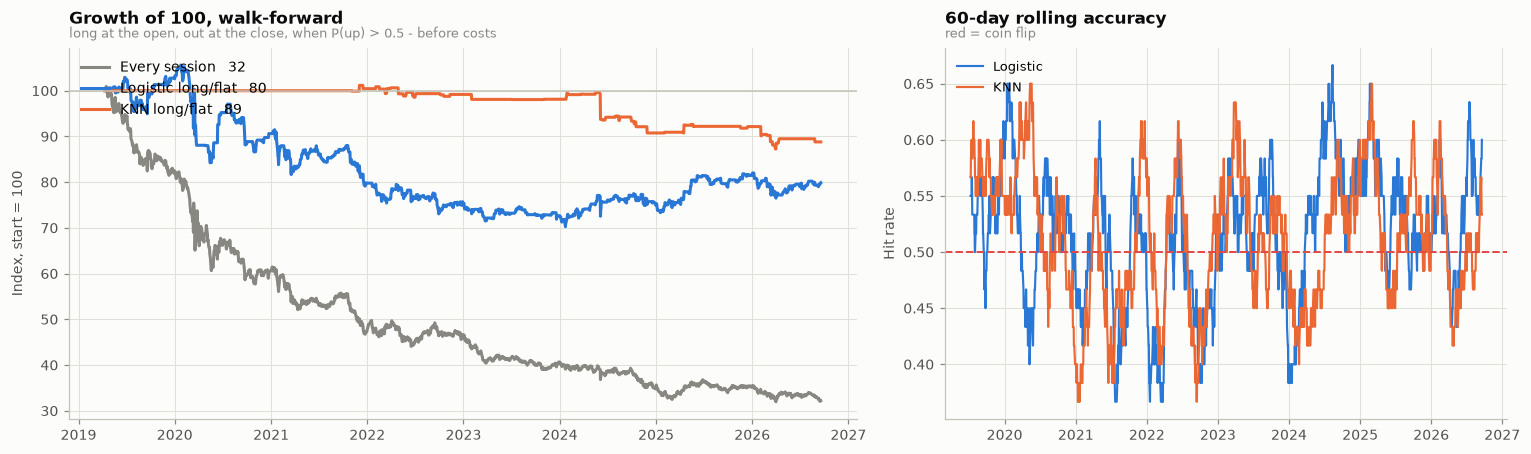

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

ax = style(axes[0], "Growth of 100, walk-forward",
           "long at the open, out at the close, when P(up) > 0.5 - before costs")
r_oc = wf["oc"].values
bh = np.cumprod(1 + r_oc) * 100                                  # hold the session daily
ax.plot(wf.index, bh, color=MUTED, label=f"Every session   {bh[-1]:.0f}")
for (name, w), colr in zip(wfs.items(), [BLUE, ORANGE]):
    curve = np.cumprod(1 + np.where(w["pred"] == 1, w["oc"].values, 0.0)) * 100
    ax.plot(w.index, curve, color=colr, label=f"{name} long/flat   {curve[-1]:.0f}")
ax.axhline(100, color=AXIS, lw=1)
ax.set_ylabel("Index, start = 100"); ax.legend(loc="upper left")

ax = style(axes[1], "60-day rolling accuracy", "red = coin flip")
for (name, w), colr in zip(wfs.items(), [BLUE, ORANGE]):
    ax.plot(w.index, w["hit"].rolling(60).mean(), color=colr, lw=1.4, label=name)
ax.axhline(0.5, color=RED, ls="--", lw=1.3)
ax.set_ylabel("Hit rate"); ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()

### Does the block ranking survive?

The ablation in §5 ranked the blocks on a single 467-day split. Walk-forward covers
1,836 days, so it is the better judge. If the ranking flips, the differences in §5 were
noise rather than signal — worth knowing before building anything on them.

In [18]:
for label, cols in [("A. price only", PRICE),
                    ("B. + global  ", PRICE + GLOBAL),
                    ("C. + flows   ", PRICE + GLOBAL + FLOW)]:
    w = walk_forward(lambda: LogisticRegression(
        max_iter=3000, C=0.01, class_weight="balanced", random_state=SEED), cols)
    print(f"  {label}  accuracy {w['hit'].mean():.2%}   "
          f"AUC {roc_auc_score(w['y'], w['proba']):.4f}")

  A. price only  accuracy 53.05%   AUC 0.5271


  B. + global    accuracy 51.91%   AUC 0.5176


  C. + flows     accuracy 52.89%   AUC 0.5323


The ranking does **not** hold: block C, which came last on the single split, does best
here, and block B's apparent advantage disappears. The honest reading is that the gaps
between the blocks in §5 are inside the noise band for a 467-day sample — roughly ±0.04
of AUC — and none of them is established. What survives both views is only the weak,
consistent signal in the price and global blocks together, worth a couple of AUC points
over chance at most.

### Costs

A model that trades the open-to-close session turns over the whole book every day it is
long. At Indian retail rates, round-trip brokerage plus STT, exchange fees and slippage
runs roughly **0.05–0.10%** per trade. Against a mean absolute session move near 0.5%,
that is a meaningful tax, and it is the reason a small edge in AUC does not automatically
become a strategy.

In [19]:
mean_abs = wf["oc"].abs().mean()
days_long = int((wf["pred"] == 1).sum())
print(f"mean |open-to-close| move : {mean_abs:.3%}")
print(f"days long                 : {days_long:,} of {len(wf):,} ({days_long/len(wf):.1%})")
for cost in (0.0005, 0.0010):
    net = np.cumprod(1 + np.where(wf["pred"] == 1, wf["oc"].values - cost, 0.0))[-1] * 100
    print(f"growth of 100 at {cost*100:.2f}% round trip : {net:7.1f}")

mean |open-to-close| move : 0.589%
days long                 : 812 of 1,836 (44.2%)
growth of 100 at 0.05% round trip :    53.2
growth of 100 at 0.10% round trip :    35.4


## 9. Verdict

In [20]:
summary = combined.copy()
summary["vs_baseline_acc"] = summary["accuracy"] - base
print(f"test base rate (always-up): {base:.2%}")
print(f"walk-forward, block B:")
for name, w in wfs.items():
    print(f"   {name:9s} accuracy {w['hit'].mean():.2%}   "
          f"AUC {roc_auc_score(w['y'], w['proba']):.4f}")
print()
summary[["model", "n_features", "params", "cv_auc", "test_auc",
         "accuracy", "balanced_acc", "vs_baseline_acc"]].round(4)

test base rate (always-up): 53.32%
walk-forward, block B:
   Logistic  accuracy 51.91%   AUC 0.5176
   KNN       accuracy 51.42%   AUC 0.4958



,model,n_features,params,cv_auc,test_auc,accuracy,balanced_acc,vs_baseline_acc
name,,,,,,,,
A. Price only,knn,11,"k=300, uniform",0.5082,0.5674,0.5525,0.5238,0.0193
B. + Global / overnight,logistic,18,C=1e-04,0.5090,0.5613,0.5503,0.5512,0.0171
A. Price only,logistic,11,C=3e-02,0.5194,0.5502,0.5503,0.5472,0.0171
gap alone (1 feature),logistic,1,C=1e-04,0.4622,0.5029,0.5182,0.5105,-0.0150
B. + Global / overnight,knn,18,"k=300, uniform",0.5135,0.4971,0.5310,0.5017,-0.0021
C. + FII/DII flows,knn,27,"k=200, distance",0.5188,0.4938,0.5118,0.5016,-0.0214
C. + FII/DII flows,logistic,27,C=1e+01,0.5262,0.4907,0.5246,0.5054,-0.0086
"Global + flows, no price",logistic,16,C=1e+02,0.5117,0.4738,0.4904,0.4804,-0.0428


## 10. The finding that outranks the model

Splitting the day to build a better target surfaced something larger than any of the
models above. Look again at the base rates from section 3:

| Window | Up rate | Annualised drift |
|---|---|---|
| Overnight (close → open) | **66.7%** | **+27.5%** |
| Intraday (open → close) | 47.4% | −15.1% |
| Full day (close → close) | 54.0% | +12.4% |

**Essentially all of NIFTY's decade of gains happened while the market was shut.** The
open-to-close session, in aggregate, lost money. This is the *overnight drift* — a
documented anomaly across many equity markets, and unusually stark here.

It also explains why v2's intraday strategy lost money even with a real edge: the session
it trades has negative drift, so a 53% hit rate is fighting a headwind.

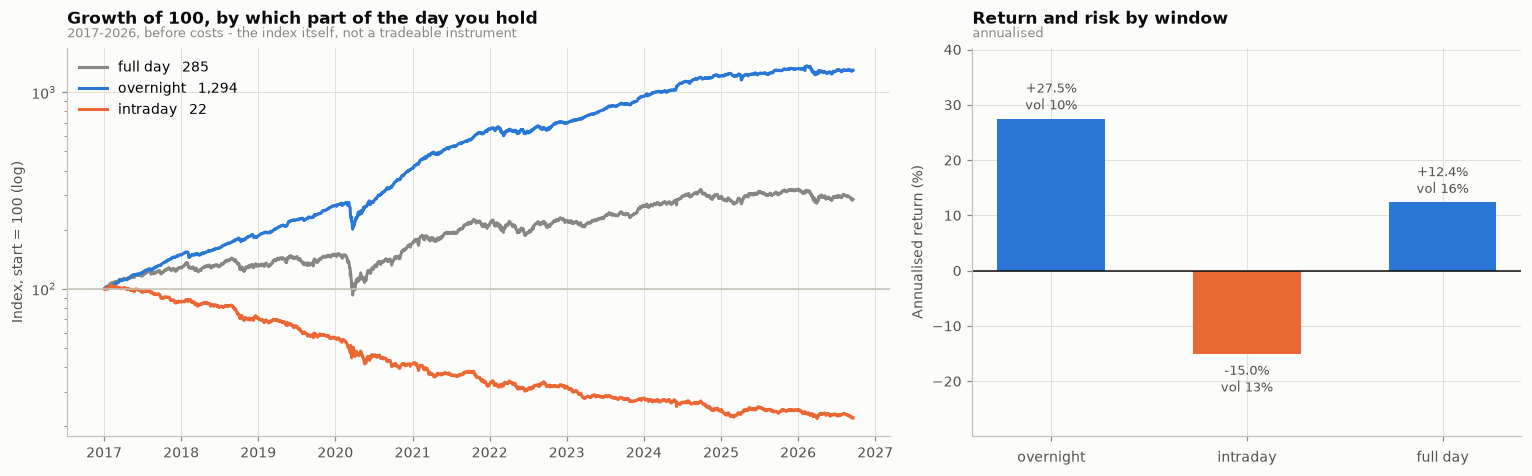

,mean,vol,ratio
overnight,27.49,10.32,2.66
intraday,-15.05,13.06,-1.15
full day,12.37,16.25,0.76


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})

parts = pd.DataFrame({"overnight": gap, "intraday": oc,
                      "full day": cc}).dropna()

ax = style(axes[0], "Growth of 100, by which part of the day you hold",
           "2017-2026, before costs - the index itself, not a tradeable instrument")
for name, colr in [("full day", MUTED), ("overnight", BLUE), ("intraday", ORANGE)]:
    curve = np.cumprod(1 + parts[name].values) * 100
    ax.plot(parts.index, curve, color=colr, label=f"{name}   {curve[-1]:,.0f}")
ax.axhline(100, color=AXIS, lw=1)
ax.set_yscale("log"); ax.set_ylabel("Index, start = 100 (log)")
ax.legend(loc="upper left")

ax = style(axes[1], "Return and risk by window", "annualised")
stats = pd.DataFrame({
    "mean": parts.mean() * 252 * 100,
    "vol": parts.std() * np.sqrt(252) * 100,
})
stats["ratio"] = stats["mean"] / stats["vol"]
xs = np.arange(len(stats))
cols = [BLUE if v > 0 else ORANGE for v in stats["mean"]]
bars = ax.bar(xs, stats["mean"], color=cols, width=0.55)
span = stats["mean"].max() - stats["mean"].min()
ax.set_ylim(stats["mean"].min() - span * 0.35, stats["mean"].max() + span * 0.30)
for b, (m, v, r) in zip(bars, stats.values):
    ax.text(b.get_x() + b.get_width() / 2,
            m + (span * 0.04 if m > 0 else -span * 0.16),
            f"{m:+.1f}%\nvol {v:.0f}%", ha="center", fontsize=8.5, color=INK2)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(xs, stats.index)
ax.tick_params(axis="x", pad=6)
ax.set_ylabel("Annualised return (%)")
plt.tight_layout(); plt.show()

stats.round(2)